# 3D Phantom Generation

Creates four 3D phantoms for CT simulation:
- **Three spheres** (`three_spheres.raw`): three spheres at asymmetric positions with different sizes and material IDs
- **Single sphere** (`single_sphere.raw`): one centered sphere at uniform density
- **Shepp-Logan** (`shepp_logan.raw`): 3D Shepp-Logan from the TomoPhantom library (Model 13), values in [0, 60]
- **Shepp-Logan flat** (`shepp_logan_flat.raw`): same shape, all nonzero voxels set to 40

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import os

import tomophantom
from tomophantom import TomoP3D

## Parameters

In [21]:
N_size = 150    # volume size in voxels (each side)
vox_size = 0.1  # voxel size in cm

path_library3D = os.path.join(os.path.dirname(tomophantom.__file__), "phantomlib", "Phantom3DLibrary.dat")
print(f"Volume: {N_size}³ voxels, voxel size: {vox_size} cm")
print("TomoPhantom library:", path_library3D)

Volume: 150³ voxels, voxel size: 0.1 cm
TomoPhantom library: /home/josea/miniconda3/lib/python3.12/site-packages/tomophantom/phantomlib/Phantom3DLibrary.dat


## Phantom 1: Three Spheres

In [22]:
phantom_3D = np.zeros((N_size, N_size, N_size), dtype=np.uint8)

z, y, x = np.ogrid[0:N_size, 0:N_size, 0:N_size]

balls = [
    # (x_center, y_center, z_center, radius, material_id)
    (40,  50,  45,  10, 10),   # small
    (90,  60,  65,  20, 20),   # medium
    (55, 100,  90,  15, 30),   # large-ish
]

for cx, cy, cz, r, mat_id in balls:
    mask = (x - cx)**2 + (y - cy)**2 + (z - cz)**2 < r**2
    phantom_3D[mask] = mat_id

print(f"Shape: {phantom_3D.shape}, dtype: {phantom_3D.dtype}")
print(f"Unique material IDs: {np.unique(phantom_3D)}")

Shape: (150, 150, 150), dtype: uint8
Unique material IDs: [ 0 10 20 30]


### Visualize

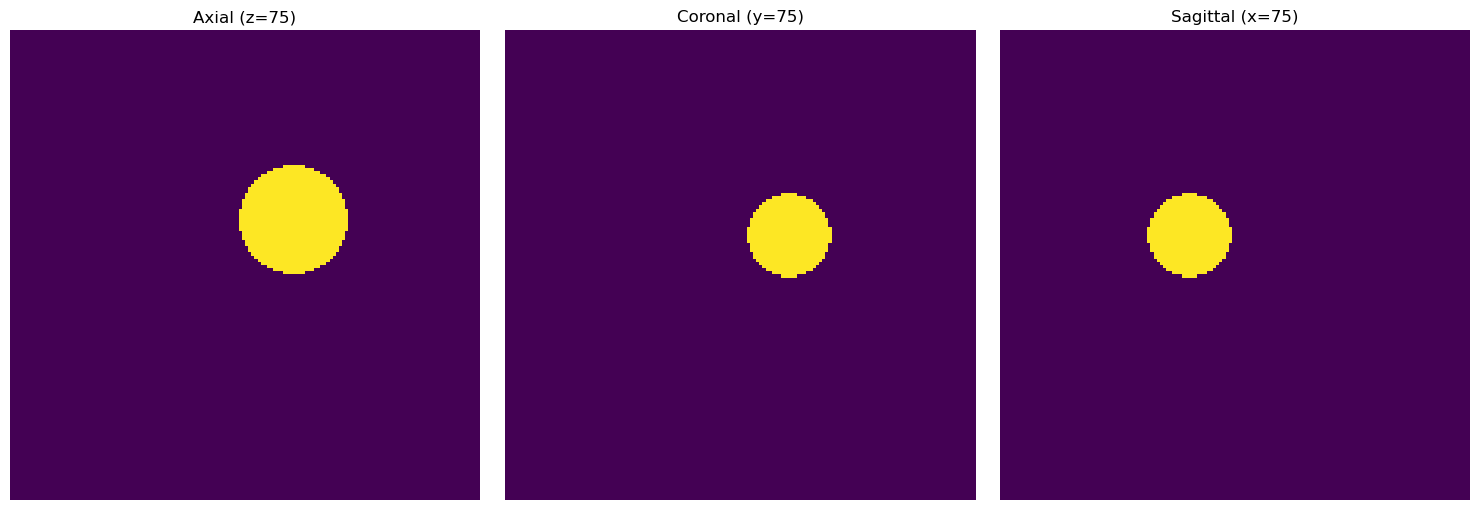

In [23]:
mid = N_size // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(phantom_3D[mid, :, :], cmap="viridis")
axes[0].set_title(f"Axial (z={mid})")

axes[1].imshow(phantom_3D[:, mid, :], cmap="viridis")
axes[1].set_title(f"Coronal (y={mid})")

axes[2].imshow(phantom_3D[:, :, mid], cmap="viridis")
axes[2].set_title(f"Sagittal (x={mid})")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Phantom 2: Single Sphere

In [24]:
sphere_img = np.zeros((N_size, N_size, N_size), dtype=np.float32)
cx, cy, cz = N_size // 2, N_size // 2, N_size // 2
radius = 25  # voxels

ix, iy, iz = np.ogrid[0:N_size, 0:N_size, 0:N_size]
sphere_mask = (ix - cx)**2 + (iy - cy)**2 + (iz - cz)**2 < radius**2
sphere_img[sphere_mask] = 40.0
sphere_img = sphere_img.astype(np.uint8)

print(f"Center: ({cx},{cy},{cz}), radius={radius} voxels ({radius*vox_size:.1f} cm)")
print(f"Nonzero voxels: {int(sphere_mask.sum())}")

Center: (75,75,75), radius=25 voxels (2.5 cm)
Nonzero voxels: 65117


### Visualize

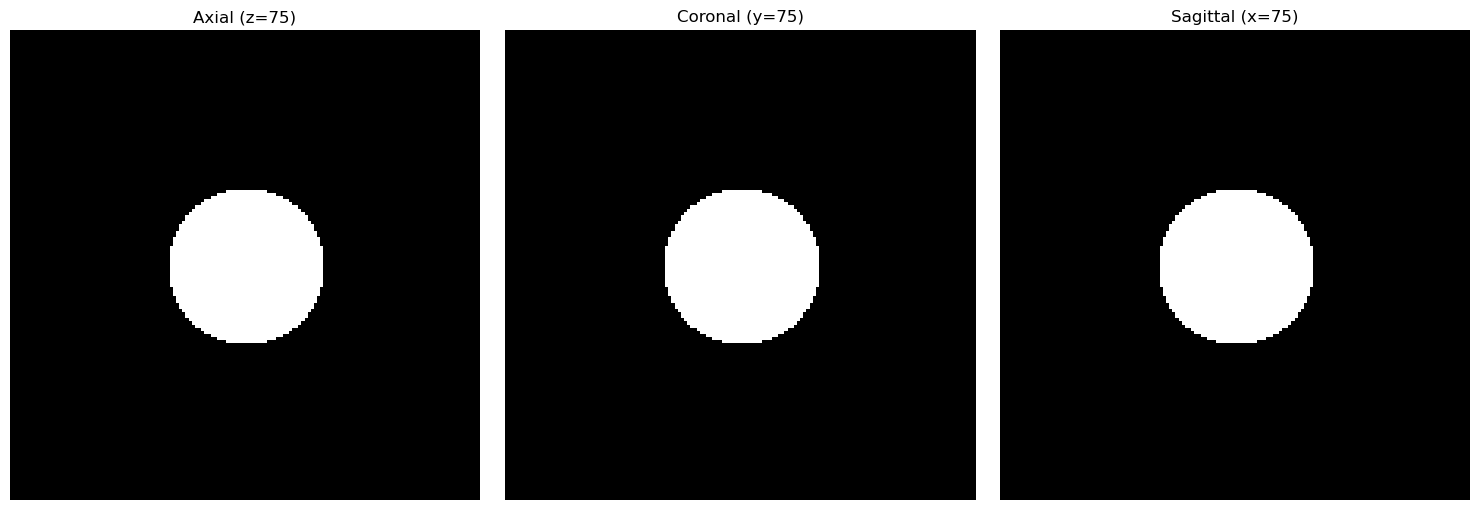

In [25]:
mid = N_size // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sphere_img[mid, :, :], cmap="gray")
axes[0].set_title(f"Axial (z={mid})")
axes[1].imshow(sphere_img[:, mid, :], cmap="gray")
axes[1].set_title(f"Coronal (y={mid})")
axes[2].imshow(sphere_img[:, :, mid], cmap="gray")
axes[2].set_title(f"Sagittal (x={mid})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Phantom 3: TomoPhantom Library — 3D Shepp-Logan (Model 13)

In [26]:
shepp_logan_f32 = TomoP3D.Model(13, N_size, path_library3D)

# Scale float32 output to [0, 60] then cast to uint8
vmin, vmax = shepp_logan_f32.min(), shepp_logan_f32.max()
shepp_logan = ((shepp_logan_f32 - vmin) / (vmax - vmin) * 60).astype(np.uint8)

print(f"Shape: {shepp_logan.shape}, dtype: {shepp_logan.dtype}")
print(f"Value range: [{shepp_logan.min()}, {shepp_logan.max()}]")

Shape: (150, 150, 150), dtype: uint8
Value range: [0, 60]


### Visualize

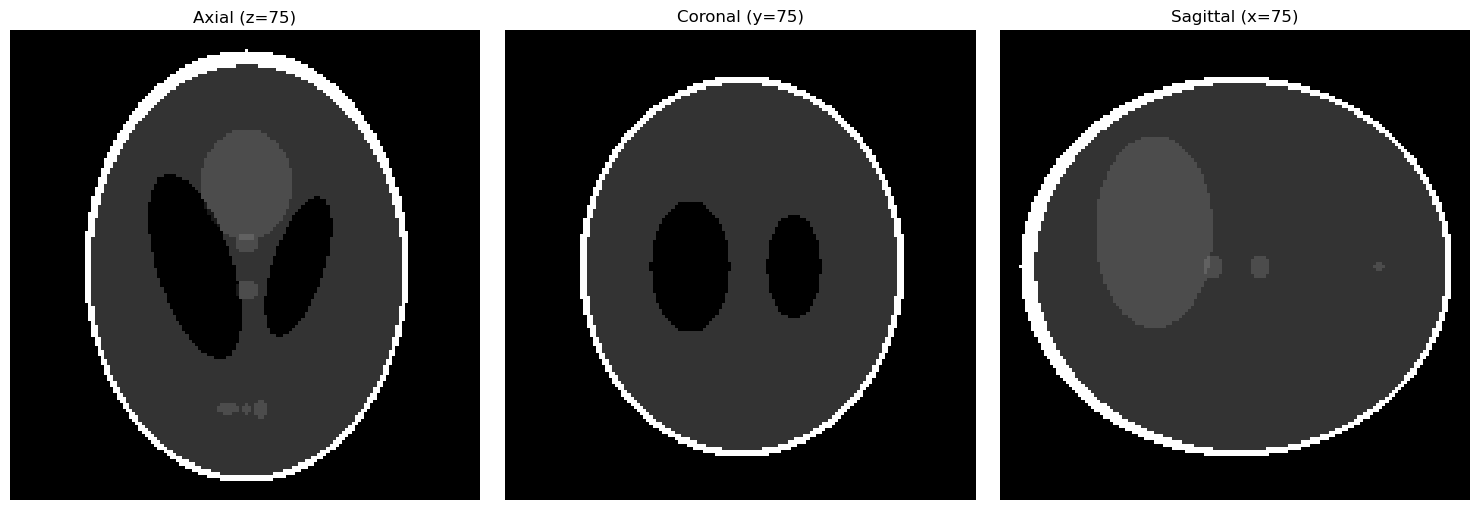

In [27]:
mid = N_size // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(shepp_logan[mid, :, :], cmap="gray")
axes[0].set_title(f"Axial (z={mid})")
axes[1].imshow(shepp_logan[:, mid, :], cmap="gray")
axes[1].set_title(f"Coronal (y={mid})")
axes[2].imshow(shepp_logan[:, :, mid], cmap="gray")
axes[2].set_title(f"Sagittal (x={mid})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Phantom 4: Shepp-Logan Flat (all nonzero = 40)

In [28]:
# Flat Shepp-Logan: same shape as the original but all nonzero voxels set to 40
shepp_logan_flat = np.where(shepp_logan > 0, 40, 0).astype(np.uint8)

print(f"Shape: {shepp_logan_flat.shape}, dtype: {shepp_logan_flat.dtype}")
print(f"Unique values: {np.unique(shepp_logan_flat)}")

Shape: (150, 150, 150), dtype: uint8
Unique values: [ 0 40]


### Visualize

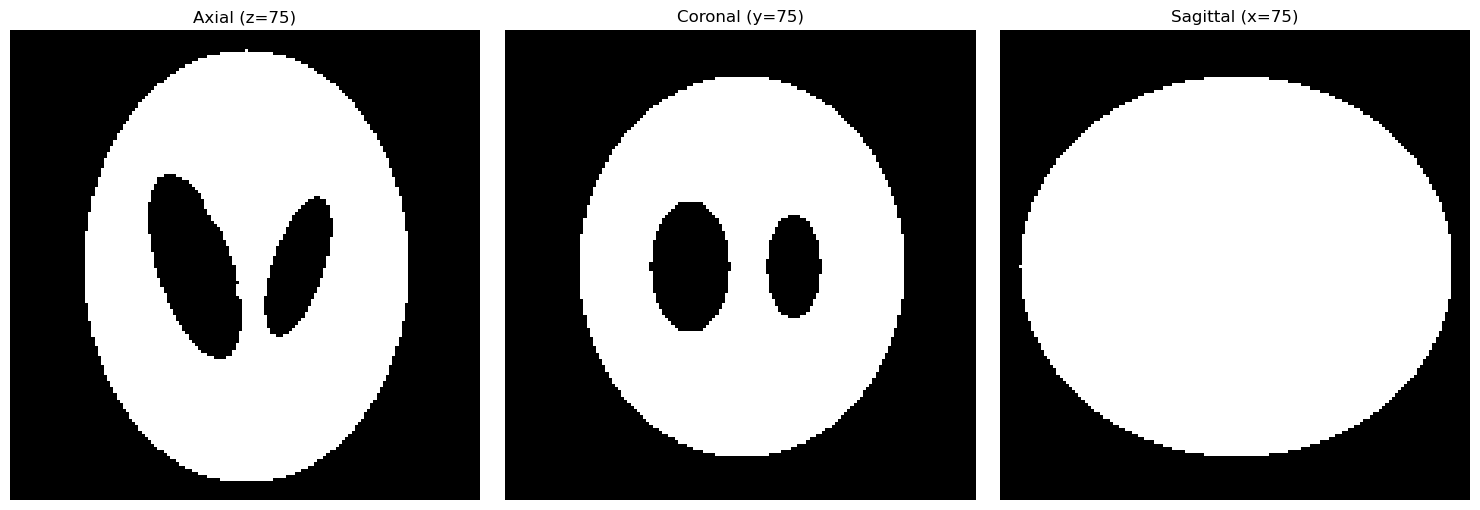

In [29]:
mid = N_size // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(shepp_logan_flat[mid, :, :], cmap="gray")
axes[0].set_title(f"Axial (z={mid})")
axes[1].imshow(shepp_logan_flat[:, mid, :], cmap="gray")
axes[1].set_title(f"Coronal (y={mid})")
axes[2].imshow(shepp_logan_flat[:, :, mid], cmap="gray")
axes[2].set_title(f"Sagittal (x={mid})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Save

In [30]:
phantom_3D.astype(np.uint8).tofile("three_spheres.raw")
print(f"Saved three_spheres.raw ({phantom_3D.nbytes / 1e6:.1f} MB, shape={phantom_3D.shape}, dtype={phantom_3D.dtype})")

sphere_img.tofile("single_sphere.raw")
print(f"Saved single_sphere.raw ({sphere_img.nbytes / 1e6:.1f} MB, shape={sphere_img.shape}, dtype={sphere_img.dtype})")

shepp_logan.tofile("shepp_logan.raw")
print(f"Saved shepp_logan.raw ({shepp_logan.nbytes / 1e6:.1f} MB, shape={shepp_logan.shape}, dtype={shepp_logan.dtype})")

shepp_logan_flat.tofile("shepp_logan_flat.raw")
print(f"Saved shepp_logan_flat.raw ({shepp_logan_flat.nbytes / 1e6:.1f} MB, shape={shepp_logan_flat.shape}, dtype={shepp_logan_flat.dtype})")

# Save a blank (zero) image of the same size
blank = np.zeros_like(sphere_img)
blank.tofile("blank_3D.raw")
print(f"Saved blank_3D.raw ({blank.nbytes / 1e6:.1f} MB)")

Saved three_spheres.raw (3.4 MB, shape=(150, 150, 150), dtype=uint8)
Saved single_sphere.raw (3.4 MB, shape=(150, 150, 150), dtype=uint8)
Saved shepp_logan.raw (3.4 MB, shape=(150, 150, 150), dtype=uint8)
Saved shepp_logan_flat.raw (3.4 MB, shape=(150, 150, 150), dtype=uint8)
Saved blank_3D.raw (3.4 MB)
